In [3]:
import os
os.environ["OMP_NUM_THREADS"] = '3'

import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, hamming_loss


In [1]:
Questionaire = {
    'Q0': "For learning : I prefer learner’s engagement.",
    'Q1': "For learning : I prefer watching online video.",
    'Q2': "For learning : I prefer reading books.",
    'Q3': "For learning : I prefer reading online articles.",
    'Q4': "For learning : I prefer doing own research.",
    'Q5': "For learning : I prefer listening to experts.",
    'Q6': "For learning : I prefer online group discussion.",
    'Q7': "For learning : I prefer web-based interactive materials.",
    'Q8': "For learning : I prefer Q&A sessions.",
    'Q9': "For learning : I prefer group projects.",
    'Q10': "For learning : I prefer case studies.",
    'Q11': "For learning : I prefer problem-based learning.",
    'Q12': "For learning : I prefer examples and applications.",
    'Q13': "For learning : I prefer independent learning.",
    'Q14': "For learning : I prefer simulation.",
    'Q15': "My response to images and graphics for learning : I like learning by visualization, like use of pictures, videos, slides.",
    'Q16': "My response to images and graphics for learning : I like learning by using diagrams, graphs and charts.",
    'Q17': "My response to images and graphics for learning : I follow written directions better than oral directions.",
    'Q18': "My response to images and graphics for learning : I can better understand and follow directions using maps.",
    'Q19': "My response to images and graphics for learning : I like reading lists, bullet points and numbered paragraphs.",
    'Q20': "My response to images and graphics for learning : When learning from Internet, I like videos showing how to do.",
    'Q21': "My response for verbal presentations for learning : I can remember more by listening than reading.",
    'Q22':	"My response for verbal presentations for learning : I do better at academic subjects by listening to lectures.",
    'Q23': "My response for verbal presentations for learning : I like listen to a good lecture than read about the same material.",
    'Q24': "My response for verbal presentations for learning : I prefer listening a news on radio than reading it in a newspaper.",
    'Q25': "My response for physical approaches for learning : I like attending labs and practical session.",
    'Q26':	"My response for physical approaches for learning : I like to make visuals (concept maps, charts, graphs and models).",
    'Q27': "My response for physical approaches for learning : I like to participate in games for learning.",
    'Q28': "My response for physical approaches for learning : I prefer to learns by doing, and involving directly.",
    'Q29': "I think : I am satisfied with the way I am learning in my institution.",				
    'Q30':	"I think : the quality of education in my institution should be better.",
    'Q31':	"I think : there are better ways of learning other than the way I follow now."
}

LSQ = {'Q0':'K', 'Q1':'V', 'Q2':'R', 'Q3':'R','Q4':'K', 'Q5':'A', 'Q6':'K', 'Q7':'V', 'Q8':'K', 'Q9':'K', 'Q10':'K', 'Q11':'K', 'Q12': 'K', 'Q13':'K', 'Q14':'V',
       'Q15':'V','Q16': 'V', 'Q17':'R','Q18': 'V', 'Q19': 'V', 'Q20': 'V',
       'Q21':'A','Q22': 'A', 'Q23':'A','Q24':'A', 'Q25':'K','Q26':'V','Q27':'K'}

Prob_dist = {'SA': 1.00, 'A': 0.75, 'N': 0.50, 'D': 0.25, 'SD': 0.00}

In [15]:
# Parameters
num_students = 1000
num_questions = 28
learning_styles = ["Visual", "Auditorial", "Reading", "Kinesthetic"]

# Define learning style proportions
learning_style_distribution = {
    "Visual": 0.30,
    "Auditorial": 0.20,
    "Reading": 0.20,
    "Kinesthetic": 0.15,
    "Mixed": 0.15
}

# Assign primary learning styles to students
students = []
for style, proportion in learning_style_distribution.items():
    count = int(num_students * proportion)
    students.extend([style] * count)
np.random.shuffle(students)

# Map questions to learning styles
# question_weights = {
#     "Visual": list(range(1, 8)),
#     "Auditorial": list(range(8, 15)),
#     "Reading": list(range(15, 22)),
#     "Kinesthetic": list(range(22, 29))
# }
question_weights = {
    "Visual": [key for key, val in LSQ.items() if val == 'V'],
    "Auditorial": [key for key, val in LSQ.items() if val == 'A'],
    "Reading": [key for key, val in LSQ.items() if val == 'R'],
    "Kinesthetic": [key for key, val in LSQ.items() if val == 'K']
}

# Generate responses
# Strongly Agree 1.00
# Agree 0.75
# Neutral 0.5
# Disagree 0.25
# Strongly disagree 0.00

# Function to generate response
def generate_response(preferences, question):
    # Bias responses for preferred learning styles
    for style, questions in question_weights.items():
        if question in questions:
            if style in preferences:
                return np.random.choice([1.00, 0.75, 0.50], p=[0.1, 0.4, 0.5])  # Strong bias
            else:
                return np.random.choice([0.50, 0.25, 0.00], p=[0.5, 0.4, 0.1])  # Weak bias
    return 0.50  # Neutral for unclassified questions

# Create dataset
data = []
for student_id, style in enumerate(students, start=1):
    if style == "Mixed":
        preferences = np.random.choice(learning_styles, size=np.random.randint(2, 4), replace=False)
    else:
        preferences = [style]
    responses = [generate_response(preferences, f"Q{q}") for q in range(0, num_questions)]
    data.append([student_id, style, *responses])

# Convert to DataFrame
columns = ["Student_ID", "Learning_Style"] + [f"Q{q}" for q in range(0, num_questions)]
df = pd.DataFrame(data, columns=columns)


In [16]:
df[['Visual', 'Auditorial', 'Reading', 'Kinesthetic']] = 0

for student in range(df.shape[0]):
    for style in question_weights:
        scores = [df.loc[student, Q] for Q in question_weights[style]]
        prob = sum(scores)/len(scores)
        df.loc[student, style] = prob


C:\Users\Tanima\AppData\Local\Temp\ipykernel_29396\411084751.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6666666666666666' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[student, style] = prob
C:\Users\Tanima\AppData\Local\Temp\ipykernel_29396\411084751.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.45' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[student, style] = prob
C:\Users\Tanima\AppData\Local\Temp\ipykernel_29396\411084751.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[student, style] = prob
C:\Users\

In [17]:
df

,Student_ID,Learning_Style,Q0,Q1,Q2,Q3,Q4,Q5,Q6,Q7,...,Q22,Q23,Q24,Q25,Q26,Q27,Visual,Auditorial,Reading,Kinesthetic
0,1,Visual,0.25,0.75,0.25,0.25,0.50,0.50,0.50,0.75,...,0.25,0.50,0.50,0.50,0.50,0.50,0.666667,0.45,0.333333,0.340909
1,2,Kinesthetic,0.50,0.50,0.25,0.25,0.75,0.50,0.75,0.25,...,0.50,0.50,0.00,1.00,0.50,1.00,0.388889,0.40,0.333333,0.704545
2,3,Reading,0.50,0.25,0.75,0.50,0.50,0.50,0.25,0.50,...,0.25,0.50,0.25,0.25,0.50,0.25,0.333333,0.40,0.666667,0.386364
3,4,Visual,0.50,0.50,0.50,0.50,0.50,0.25,0.50,0.75,...,0.50,0.50,0.00,0.50,0.75,0.00,0.638889,0.35,0.500000,0.409091
4,5,Mixed,0.50,0.50,0.75,0.75,1.00,0.25,0.50,0.50,...,0.25,0.25,0.25,0.75,0.50,0.75,0.361111,0.30,0.666667,0.659091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Kinesthetic,0.50,0.50,0.50,0.00,0.50,0.50,1.00,0.50,...,0.50,0.50,0.50,0.50,0.50,0.50,0.361111,0.50,0.250000,0.681818
996,997,Visual,0.25,0.50,0.25,0.50,0.25,0.25,0.50,0.50,...,0.50,0.50,0.25,0.50,0.50,0.50,0.611111,0.40,0.333333,0.409091
997,998,Visual,0.25,0.75,0.00,0.50,0.50,0.50,0.25,0.75,...,0.50,0.50,0.50,0.50,0.50,0.25,0.638889,0.45,0.333333,0.363636
998,999,Mixed,0.75,0.25,1.00,0.50,0.50,1.00,0.50,0.50,...,0.75,0.50,0.75,0.75,0.50,1.00,0.305556,0.70,0.750000,0.704545


In [18]:
# Select input and output columns
X = df.loc[:, 'Q0':'Q27']
y = df[['Visual', 'Auditorial', 'Reading', 'Kinesthetic']]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [19]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Train a separate SVR model for each output
y_pred_scaled = np.zeros(y_test.shape)

for i, target in enumerate(y.columns):
    print(f"Training SVR model for {target}...")
    svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
    svr_model.fit(X_train_scaled, y_train_scaled[:, i])

    # Predictions
    y_pred_scaled[:, i] = svr_model.predict(X_test_scaled)

# Inverse scaling
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Evaluation
for i, target in enumerate(y.columns):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"\nTarget: {target}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")

print("\nMulti-output SVR regression completed.")

Training SVR model for Visual...
Training SVR model for Auditorial...
Training SVR model for Reading...
Training SVR model for Kinesthetic...

Target: Visual
Mean Squared Error: 0.0008
R2 Score: 0.9679

Target: Auditorial
Mean Squared Error: 0.0007
R2 Score: 0.9695

Target: Reading
Mean Squared Error: 0.0013
R2 Score: 0.9499

Target: Kinesthetic
Mean Squared Error: 0.0007
R2 Score: 0.9606

Multi-output SVR regression completed.


## DT

In [20]:
from sklearn.tree import DecisionTreeRegressor

# Train a separate Decision Tree model for each output
y_pred = np.zeros(y_test.shape)

for i, target in enumerate(y.columns):
    print(f"Training Decision Tree model for {target}...")
    dt_model = DecisionTreeRegressor(random_state=42)
    dt_model.fit(X_train, y_train.iloc[:, i])

    # Predictions
    y_pred[:, i] = dt_model.predict(X_test)

# Evaluation
for i, target in enumerate(y.columns):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"\nTarget: {target}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")

print("\nMulti-output Decision Tree regression completed.")

Training Decision Tree model for Visual...
Training Decision Tree model for Auditorial...
Training Decision Tree model for Reading...
Training Decision Tree model for Kinesthetic...

Target: Visual
Mean Squared Error: 0.0021
R2 Score: 0.9166

Target: Auditorial
Mean Squared Error: 0.0015
R2 Score: 0.9321

Target: Reading
Mean Squared Error: 0.0000
R2 Score: 1.0000

Target: Kinesthetic
Mean Squared Error: 0.0033
R2 Score: 0.8193

Multi-output Decision Tree regression completed.


## RF

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Train a separate Random Forest model for each output
y_pred = np.zeros(y_test.shape)

for i, target in enumerate(y.columns):
    print(f"Training Random Forest model for {target}...")
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train.iloc[:, i])

    # Predictions
    y_pred[:, i] = rf_model.predict(X_test)

# Evaluation
for i, target in enumerate(y.columns):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"\nTarget: {target}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")

print("\nMulti-output Random Forest regression completed.")


Training Random Forest model for Visual...
Training Random Forest model for Auditorial...
Training Random Forest model for Reading...
Training Random Forest model for Kinesthetic...

Target: Visual
Mean Squared Error: 0.0009
R2 Score: 0.9648

Target: Auditorial
Mean Squared Error: 0.0007
R2 Score: 0.9689

Target: Reading
Mean Squared Error: 0.0000
R2 Score: 0.9987

Target: Kinesthetic
Mean Squared Error: 0.0009
R2 Score: 0.9486

Multi-output Random Forest regression completed.


## ANN

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Build the ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train_scaled.shape[1], activation='linear'))

# Compile the model
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train_scaled, 
                    y_train_scaled, 
                    validation_data=[X_test_scaled, y_test_scaled], 
                    epochs=100, 
                    batch_size=16, 
                    callbacks = [early_stop],
                    verbose=1)

# Predictions
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Evaluation
for i, target in enumerate(y.columns):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"\nTarget: {target}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")

print("\nMulti-output ANN regression completed.")


Epoch 1/100
50/50 [==============================] - 1s 5ms/step - loss: 0.5609 - val_loss: 0.2559
Epoch 2/100
50/50 [==============================] - 0s 3ms/step - loss: 0.1616 - val_loss: 0.1198
Epoch 3/100
50/50 [==============================] - 0s 3ms/step - loss: 0.0870 - val_loss: 0.0794
Epoch 4/100
50/50 [==============================] - 0s 4ms/step - loss: 0.0598 - val_loss: 0.0619
Epoch 5/100
50/50 [==============================] - 0s 4ms/step - loss: 0.0442 - val_loss: 0.0493
Epoch 6/100
50/50 [==============================] - 0s 4ms/step - loss: 0.0349 - val_loss: 0.0420
Epoch 7/100
50/50 [==============================] - 0s 4ms/step - loss: 0.0285 - val_loss: 0.0356
Epoch 8/100
50/50 [==============================] - 0s 4ms/step - loss: 0.0245 - val_loss: 0.0321
Epoch 9/100
50/50 [==============================] - 0s 4ms/step - loss: 0.0210 - val_loss: 0.0288
Epoch 10/100
50/50 [==============================] - 0s 4ms/step - loss: 0.0181 - val_loss: 0.0259
Epoch 11/

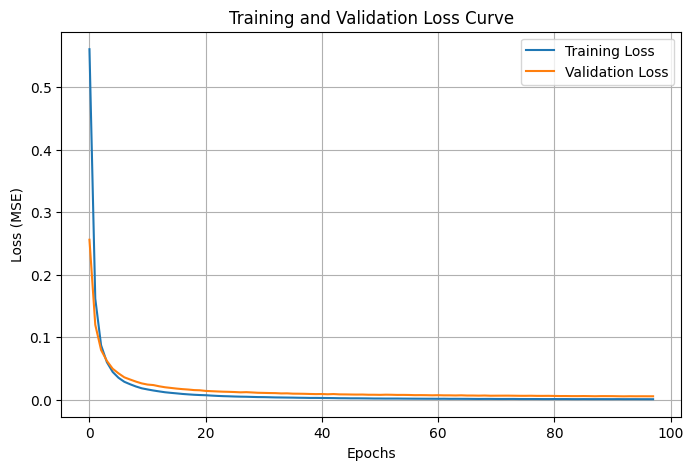

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()